# Parallax Risk — Variance reduction and convergence

Phase 4 synthetic GBM terminal positive-part statistic. The reference is the undiscounted expectation of `(S_T-K)+` under the explicit drift. It is a research statistic, not a portfolio pricing or exposure service.

In [1]:
import pandas as pd

from parallax_risk.application.simulation_examples import (
    convergence_experiment,
    variance_experiment,
)

comparison = variance_experiment()
experiment = convergence_experiment()

## Antithetics and a separate control pilot
Antithetic inference uses adjacent pair averages. The control coefficient is fitted on 2,048 separate pilot paths, then frozen for evaluation. Its known expectation is analytical. Gains below are measured estimator variance ratios. The work adjustment includes pilot paths; it does not measure elapsed-time efficiency. Antithetics and controls can worsen results for other statistics.

In [2]:
pd.DataFrame(
    [
        {
            "method": case.name,
            "mean": case.result.estimate.mean,
            "standard_error": case.result.estimate.standard_error,
            "independent_units": case.result.estimate.independent_units,
            "evaluation_paths": case.evaluation_paths,
            "pilot_paths": case.pilot_paths,
            "variance_gain": case.variance_gain_against_plain,
            "work_adjusted_gain": case.work_adjusted_gain_against_plain,
        }
        for case in comparison.cases
    ]
)

,method,mean,standard_error,independent_units,evaluation_paths,pilot_paths,variance_gain,work_adjusted_gain
0,plain,10.836928,0.171654,8192,8192,0,1.000000,1.000000
1,antithetic,11.117465,0.121960,4096,8192,0,1.980969,1.980969
2,control,11.032126,0.065598,8192,8192,2048,6.847547,5.478038


## Nested path-count experiments
Each method uses 16 independent replicate addresses at each count. Prefixes are nested across path counts. RMSE is measured against the production analytical reference. A finite seeded slope is descriptive and does not establish a universal convergence rate. Scrambled Sobol uses complete powers of two, without skipped or thinned points, and an explicit finite-bit midpoint inverse-normal transform.

In [3]:
frame = pd.DataFrame(
    [
        {
            "method": method,
            "paths_per_replicate": row.paths_per_replicate,
            "total_paths": row.total_paths,
            "RMSE": row.root_mean_square_error,
            "bias": row.bias,
        }
        for method, study in [("pseudo", experiment.pseudo), ("Sobol", experiment.sobol)]
        for row in study.rows
    ]
)
frame

,method,paths_per_replicate,total_paths,RMSE,bias
0,pseudo,256,4096,1.081990,-0.045760
1,pseudo,1024,16384,0.576370,0.032314
2,pseudo,4096,65536,0.201930,-0.004497
3,pseudo,16384,262144,0.110237,0.017252
4,Sobol,256,4096,0.042127,-0.004557
5,Sobol,1024,16384,0.007699,-0.000428
6,Sobol,4096,65536,0.002326,-0.000110
7,Sobol,16384,262144,0.000733,0.000183


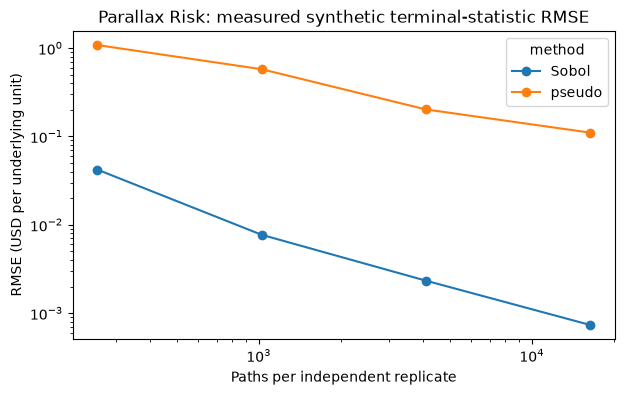

In [4]:
axes = frame.pivot(index="paths_per_replicate", columns="method", values="RMSE").plot(
    loglog=True,
    marker="o",
    figsize=(7, 4),
    title="Parallax Risk: measured synthetic terminal-statistic RMSE",
)
axes.set_xlabel("Paths per independent replicate")
axes.set_ylabel("RMSE (USD per underlying unit)");

## Sobol error estimation
Individual points in one Sobol design are dependent quadrature points; an IID path confidence interval would be misleading. The interval below is an approximate Student t interval across 16 independent scramblings. The finite-bit quadrature convention can have small discretization bias, which this interval does not include.

In [5]:
estimate = experiment.sobol_inference.estimate
pd.DataFrame(
    [
        {
            "mean": estimate.mean,
            "analytical_reference": experiment.reference_call_expectation,
            "standard_error": estimate.standard_error,
            "confidence_interval": estimate.confidence_interval,
            "independent_scramblings": estimate.independent_units,
            "total_paths": estimate.total_paths,
            "sampling_unit": estimate.sampling_unit,
            "pseudo_log_RMSE_slope": experiment.pseudo.log_rmse_slope,
            "Sobol_log_RMSE_slope": experiment.sobol.log_rmse_slope,
        }
    ]
)

,mean,analytical_reference,standard_error,confidence_interval,independent_scramblings,total_paths,sampling_unit,pseudo_log_RMSE_slope,Sobol_log_RMSE_slope
0,10.986579,10.986396,0.000183,"(10.98618900745798, 10.986969717104884)",16,262144,independent_scramble,-0.569907,-0.963198


No GPU or distributed simulation is included. See [statistics](../docs/methodology/MONTE_CARLO_STATISTICS.md), [benchmarks](../docs/validation/MONTE_CARLO_BENCHMARKS.md), and [phase evidence](../docs/validation/phase-4.md).